# PlantSegV2 SegFormer Training Notebook

This notebook is a production-oriented SegFormer fine-tuning workflow for `plantsegv2` using the local CUDA environment `F:\PyTorch_GPU\torch_gpu\Scripts\Activate.ps1`.

## Research-backed design choices

- **Architecture:** SegFormer combines a hierarchical Transformer encoder with a lightweight all-MLP decoder, which is strong for semantic segmentation while staying efficient enough for single-GPU fine-tuning.
- **Starting checkpoint:** `nvidia/segformer-b2-finetuned-ade-512-512` gives useful semantic segmentation features, then replaces the segmentation head for PlantSegV2 labels with `ignore_mismatched_sizes=True`.
- **Dataset interpretation:** mask value `0` is background; foreground values are disease IDs (`Index + 1`) from `Metadatav2.csv`. Use `TASK_MODE="multiclass"` for disease-specific segmentation or `TASK_MODE="binary"` for diseased-tissue vs background.
- **Imbalance strategy:** combine pixel-level class weights, focal loss, and image-level oversampling. This directly targets plant segmentation skew where background and common diseases dominate.
- **Metrics:** log loss, mean IoU, foreground mIoU, pixel accuracy, and mean accuracy to TensorBoard and MLflow every epoch.

Useful primary references checked while designing this:

- Hugging Face Transformers SegFormer docs: https://huggingface.co/docs/transformers/model_doc/segformer
- SegFormer paper: https://arxiv.org/abs/2105.15203
- PyTorch `CrossEntropyLoss` class weights and `ignore_index`: https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
- PyTorch TensorBoard writer: https://docs.pytorch.org/docs/stable/tensorboard.html
- MLflow PyTorch logging behavior: https://mlflow.org/docs/latest/python_api/mlflow.pytorch.html

## 1. Environment Check

Run this notebook from the repository root. If you launch Jupyter manually, activate the CUDA venv first:

```powershell
cd F:\PyTorch_GPU\Plant_desease_segmentation
. F:\PyTorch_GPU\torch_gpu\Scripts\Activate.ps1
jupyter lab
```

In [1]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
for candidate in [cwd, *cwd.parents]:
    if (candidate / "plantsegv2").exists() and (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(f"Could not find project root above: {cwd}")
DATA_ROOT = PROJECT_ROOT / "plantsegv2"
SRC_ROOT = PROJECT_ROOT / "src"
assert DATA_ROOT.exists(), f"Missing dataset root: {DATA_ROOT}"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print("Python:", sys.executable)
print("Project:", PROJECT_ROOT)
print("Dataset:", DATA_ROOT)

Python: f:\PyTorch_GPU\torch_gpu\Scripts\python.exe
Project: F:\PyTorch_GPU\Plant_desease_segmentation
Dataset: F:\PyTorch_GPU\Plant_desease_segmentation\plantsegv2


In [2]:
import torch
import transformers
import albumentations as A
import mlflow

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("albumentations:", A.__version__)
print("mlflow:", mlflow.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA build:", torch.version.cuda)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

f:\PyTorch_GPU\torch_gpu\lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


torch: 2.6.0+cu124
transformers: 4.56.1
albumentations: 2.0.4
mlflow: 3.1.4
CUDA available: True
CUDA build: 12.4
GPU: NVIDIA GeForce GTX 1650


## 2. Configuration

Start with `multiclass` when you want disease-specific segmentation. Switch to `binary` when the immediate product goal is robust diseased-region localization regardless of disease class.

For a GTX 1650, start with `batch_size=2` and `amp=False`. This GPU/model combination can produce NaN logits with AMP enabled.

In [3]:
from segformer_training import TrainConfig

# ─────────────────────────────────────────────────────────────
# BASE CONFIGURATION
# GTX 1650 notes:
#   - batch_size=2 is safe; try 4 if you have >=6 GB VRAM
#   - amp=False avoids NaN logits on this GPU / model combo
#   - num_workers=0 is required on Windows notebooks
#   - loss_name="ce_focal" is recommended; fall back to "ce" if
#     training is unstable in the first few epochs
# ─────────────────────────────────────────────────────────────
CONFIG = TrainConfig(
    data_root=str(DATA_ROOT),
    model_name="nvidia/segformer-b2-finetuned-ade-512-512",
    task_mode="multiclass",  # "binary" or "multiclass"
    image_size=512,
    batch_size=2,
    num_workers=0,  # Windows notebooks: keep at 0
    epochs=5,      # full-training epochs (smoke test uses its own epoch count)
    lr=6e-5,
    weight_decay=1e-2,
    loss_name="ce_focal",  # "ce", "focal", "ce_focal"
    use_class_weights=True,
    use_sampler=True,
    amp=False,      # GTX 1650: keep False to avoid NaN logits
    experiment_name="plantsegv2-segformer_1",
    run_name="segformer-b2-multiclass-ce-focal",
    output_dir=str(PROJECT_ROOT / "outputs" / "segformer_b2_plantsegv2_multiclass"),
    mlflow_tracking_uri="file:" + str(PROJECT_ROOT / "mlruns"),
)
CONFIG

TrainConfig(data_root='F:\\PyTorch_GPU\\Plant_desease_segmentation\\plantsegv2', model_name='nvidia/segformer-b2-finetuned-ade-512-512', task_mode='multiclass', image_size=512, batch_size=2, num_workers=0, epochs=5, lr=6e-05, weight_decay=0.01, focal_gamma=2.0, loss_name='ce_focal', focal_weight=1.0, ce_weight=0.25, use_class_weights=True, use_sampler=True, max_weight=10.0, ignore_index=255, amp=False, grad_clip_norm=1.0, seed=42, experiment_name='plantsegv2-segformer_1', run_name='segformer-b2-multiclass-ce-focal', output_dir='F:\\PyTorch_GPU\\Plant_desease_segmentation\\outputs\\segformer_b2_plantsegv2_multiclass', mlflow_tracking_uri='file:F:\\PyTorch_GPU\\Plant_desease_segmentation\\mlruns', smoke_test=False, smoke_n_samples=32)

## 3. Dataset Audit

This cell verifies that every CSV row has a matching image and mask. It also shows the disease distribution, which drives oversampling and explains why focal/weighted loss is necessary.

In [4]:
import pandas as pd
from segformer_training import load_metadata, build_label_maps

meta = load_metadata(CONFIG.data_root)
id2label, label2id = build_label_maps(meta, CONFIG.task_mode)

print("Rows with existing image+mask:", len(meta))
print("Splits:")
print(meta["split_dir"].value_counts())
print("\nNumber of labels:", len(id2label))
print("First labels:", list(id2label.items())[:10])
print("\nTop diseases:")
display(meta["Disease"].value_counts().head(20).to_frame("image_count"))
print("\nMask ratio summary:")
display(meta.groupby("split_dir")["mask_ratio"].describe())

Rows with existing image+mask: 11458
Splits:
split_dir
train    7916
test     2295
val      1247
Name: count, dtype: int64

Number of labels: 116
First labels: [(0, 'background'), (1, 'apple black rot'), (2, 'apple mosaic virus'), (3, 'apple rust'), (4, 'apple scab'), (5, 'banana anthracnose'), (6, 'banana black leaf streak'), (7, 'banana bunchy top'), (8, 'banana cigar end rot'), (9, 'banana cordana leaf spot')]

Top diseases:


,image_count
Disease,
citrus canker,390
wheat stripe rust,358
wheat head scab,319
grape downy mildew,280
wheat powdery mildew,271
apple scab,258
soybean frog eye leaf spot,238
bean rust,233
wheat septoria blotch,232



Mask ratio summary:


,count,mean,std,min,25%,50%,75%,max
split_dir,,,,,,,,
test,2295.0,0.210355,0.207554,0.000042,0.058562,0.138352,0.295896,0.994549
train,7916.0,0.216152,0.215922,0.000203,0.056921,0.136523,0.307162,1.000000
val,1247.0,0.203328,0.204234,0.001011,0.054314,0.133821,0.288356,0.998777


In [5]:
from PIL import Image
import numpy as np

for split in ["train", "val", "test"]:
    sample = meta[meta["split_dir"] == split].iloc[0]
    image = Image.open(sample["image_path"])
    mask = np.asarray(Image.open(sample["mask_path"]))
    print(
        split,
        sample["Name"],
        "image",
        image.size,
        "mask",
        mask.shape,
        "values",
        np.unique(mask)[:20],
        "max",
        mask.max(),
    )

train apple_black_rot_1.jpg image (640, 480) mask (480, 640) values [0 1] max 1
val apple_black_rot_28.jpg image (789, 500) mask (500, 789) values [0 1] max 1
test apple_black_rot_143.jpg image (268, 172) mask (172, 268) values [0 1] max 1


## 4. Class Weights and Oversampling

Pixel weights are computed from training masks and cached in `outputs/.../pixel_counts_<mode>.json`. The weighting uses clipped median-frequency balancing so rare diseases matter without making gradients explode.

In [6]:
from pathlib import Path
import numpy as np
from segformer_training import compute_pixel_counts, make_class_weights

train_frame = meta[meta["split_dir"] == "train"].copy()
counts = compute_pixel_counts(
    train_frame,
    num_labels=len(id2label),
    task_mode=CONFIG.task_mode,
    cache_path=Path(CONFIG.output_dir) / f"pixel_counts_{CONFIG.task_mode}.json",
)
weights = make_class_weights(counts, max_weight=CONFIG.max_weight)

weight_table = pd.DataFrame(
    {
        "label_id": list(range(len(id2label))),
        "label": [id2label[i] for i in range(len(id2label))],
        "pixels": counts.astype("int64"),
        "weight": weights.numpy(),
    }
)
display(weight_table.sort_values("weight", ascending=False).head(20))
display(weight_table.sort_values("pixels", ascending=False).head(20))

,label_id,label,pixels,weight
42,42,coffee black rot,76645,5.583072
43,43,coffee brown eye spot,473153,5.583072
57,57,ginger leaf spot,302214,5.583072
32,32,carrot cercospora leaf blight,763525,5.212941
36,36,celery early blight,1003592,3.965965
71,71,plum bacterial spot,1043861,3.812970
26,26,broccoli ring spot,1130204,3.521674
17,17,bell pepper frogeye leaf spot,1161770,3.425988
58,58,ginger sheath blight,1327293,2.998743
21,21,blueberry mummy berry,1485994,2.678483


,label_id,label,pixels,weight
0,0,background,5762387142,0.027915
90,90,squash powdery mildew,83321010,0.047770
87,87,soybean frog eye leaf spot,60407623,0.065889
47,47,corn rust,57254484,0.069518
108,108,wheat powdery mildew,56427551,0.070537
114,114,zucchini powdery mildew,55664995,0.071503
89,89,unused_class_89,49677249,0.080121
6,6,banana black leaf streak,43740347,0.090996
86,86,soybean downy mildew,40788899,0.097581
60,60,grape downy mildew,38393385,0.103669


## 5. Dataloaders and Batch Smoke Test

The image processor performs SegFormer normalization. Albumentations handles geometric/photometric augmentation, while masks use nearest-neighbor-safe transforms.

In [7]:
from transformers import AutoImageProcessor
from segformer_training import build_dataloaders

image_processor = AutoImageProcessor.from_pretrained(
    CONFIG.model_name,
    do_resize=False,
    do_reduce_labels=False,
    use_fast=False,
)
train_loader, val_loader, test_loader = build_dataloaders(CONFIG, meta, image_processor)

batch = next(iter(train_loader))
print(batch["pixel_values"].shape, batch["pixel_values"].dtype)
print(batch["labels"].shape, batch["labels"].dtype)
print("label values in batch:", torch.unique(batch["labels"])[:30])

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

torch.Size([2, 3, 512, 512]) torch.float32
torch.Size([2, 512, 512]) torch.int64
label values in batch: tensor([  0,  34, 113])


f:\PyTorch_GPU\torch_gpu\lib\site-packages\transformers\image_processing_base.py:410: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


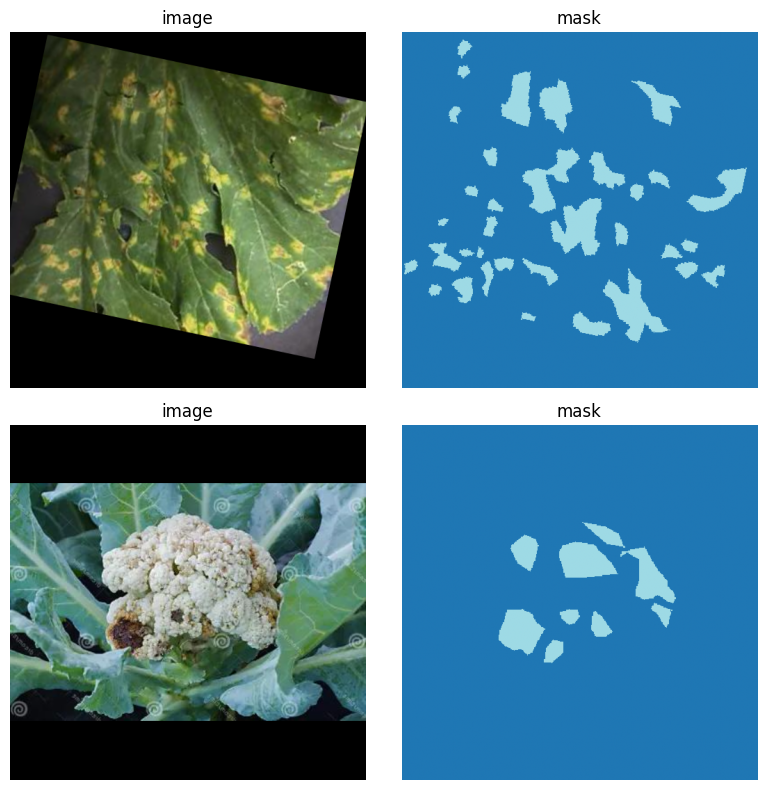

In [8]:
import matplotlib.pyplot as plt


def show_batch(batch, id2label, max_items=5):
    pixels = batch["pixel_values"][:max_items].detach().cpu()
    labels = batch["labels"][:max_items].detach().cpu().numpy()
    mean = torch.tensor(image_processor.image_mean).view(3, 1, 1)
    std = torch.tensor(image_processor.image_std).view(3, 1, 1)
    images = (pixels * std + mean).clamp(0, 1).permute(0, 2, 3, 1).numpy()

    fig, axes = plt.subplots(len(images), 2, figsize=(8, 4 * len(images)))
    if len(images) == 1:
        axes = np.expand_dims(axes, 0)
    for i in range(len(images)):
        axes[i, 0].imshow(images[i])
        axes[i, 0].set_title("image")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(labels[i], cmap="tab20")
        axes[i, 1].set_title("mask")
        axes[i, 1].axis("off")
    plt.tight_layout()


show_batch(batch, id2label)

## 6. Model and Forward Pass Smoke Test

This replaces the ADE20K head with the PlantSegV2 head. The warning about newly initialized classifier weights is expected and correct.

In [9]:
from segformer_training import create_model, forward_logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model(CONFIG, id2label, label2id).to(device)
model.eval()

with torch.no_grad():
    pixel_values = batch["pixel_values"][:1].to(device)
    labels = batch["labels"][:1].to(device)
    logits = forward_logits(model, pixel_values, labels.shape[-2:])

print("logits:", logits.shape)
print("expected classes:", len(id2label))
print("device:", device)
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([116, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([116]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


logits: torch.Size([1, 116, 512, 512])
expected classes: 116
device: cuda


## 7. Train With MLflow and TensorBoard

This is the full training cell. It logs:

- `train_loss`, `val_loss`
- `train_miou`, `val_miou`
- `train_foreground_miou`, `val_foreground_miou`
- `train_pixel_accuracy`, `val_pixel_accuracy`
- final test metrics
- best checkpoint artifacts

TensorBoard:

```powershell
. F:\PyTorch_GPU\torch_gpu\Scripts\Activate.ps1
tensorboard --logdir outputs
```

MLflow UI:

```powershell
. F:\PyTorch_GPU\torch_gpu\Scripts\Activate.ps1
mlflow ui --backend-store-uri ./mlruns
```

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 1 — SMOKE TEST (5 epochs, 32 samples)            ║
# ║  Validates the full code path in < 2 minutes.           ║
# ║  If this fails, DO NOT proceed to Stage 2.              ║
# ╚══════════════════════════════════════════════════════════╝
from segformer_training import run_smoke_test
import traceback

SMOKE_EPOCHS = 2
SMOKE_SAMPLES = 8   # total samples used across train+val+test

try:
    smoke_results = run_smoke_test(CONFIG, epochs=SMOKE_EPOCHS, n_samples=SMOKE_SAMPLES)
    SMOKE_PASSED = True
    print("\n✅ SMOKE TEST PASSED — proceeding to full training.")
except Exception:
    SMOKE_PASSED = False
    print("\n❌ SMOKE TEST FAILED — fix the error above before running full training.")
    traceback.print_exc()


# ╔══════════════════════════════════════════════════════════╗
# ║  STAGE 2 — FULL TRAINING                               ║
# ║  Only runs if the smoke test passed.                    ║
# ╚══════════════════════════════════════════════════════════╝
if SMOKE_PASSED:
    from segformer_training import train_model
    import mlflow
    import os
    import pandas as pd

    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
    mlflow.set_tracking_uri(CONFIG.mlflow_tracking_uri)
    mlflow.set_experiment(CONFIG.experiment_name)

    print("\n" + "=" * 60)
    print(f"FULL TRAINING: {CONFIG.epochs} epochs — {len(id2label)} classes")
    print("=" * 60)
    try:
        results = train_model(CONFIG)
        print("\n✅ Training complete.")
        print("Best checkpoint:", results.get("best_checkpoint", "N/A"))
        print("Best val mIoU :", f"{results.get('best_val_miou', 0):.4f}")
        print("Test metrics  :", results.get("test_metrics", {}))

        summary_path = str(Path(CONFIG.output_dir) / "training_summary.txt")
        with open(summary_path, "w") as f:
            for k, v in results.items():
                f.write(f"{k}: {v}\n")
        print(f"Summary saved → {summary_path}")
    except Exception:
        print("[ERROR] Full training failed:")
        traceback.print_exc()
        print("Reduce batch_size or image_size if you see CUDA OOM.")
else:
    print("Skipping full training — smoke test did not pass.")

SMOKE TEST: 2 epochs, ~8 samples total
Device: cuda
Labels: 116 | Task: multiclass | Smoke: True


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

f:\PyTorch_GPU\torch_gpu\lib\site-packages\transformers\image_processing_base.py:410: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


[SMOKE TEST] Using 5 train / 2 val / 2 test samples
Batches per epoch — train: 3 | val: 1 | test: 1
[SMOKE TEST] Skipping pixel count computation — using uniform class weights.


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([116, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([116]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AMP enabled: False

--- Epoch 1/2 ---


train:   0%|          | 0/3 [00:00<?, ?it/s]

: 

## 8. Fast Debug Run

Use this before committing to a full run. It trains for one epoch with the same code path, logs metrics, and catches most dataset/model issues quickly.

In [ ]:
from dataclasses import replace
from segformer_training import train_model

DEBUG_CONFIG = replace(
    CONFIG,
    epochs=1,
    batch_size=1,
    num_workers=0,
    run_name=CONFIG.run_name + "-debug",
    output_dir=str(
        Path(CONFIG.output_dir).with_name(Path(CONFIG.output_dir).name + "_debug")
    ),
)

# Uncomment for a real one-epoch CUDA debug run.
# debug_results = train_model(DEBUG_CONFIG)
# debug_results

## 9. Load Best Checkpoint and Visualize Predictions

After training, set `BEST_CHECKPOINT` to the returned checkpoint path or the best folder under `outputs/...`.

In [ ]:
from transformers import SegformerForSemanticSegmentation, AutoImageProcessor
from segformer_training import PlantSegDataset, collate_fn
from torch.utils.data import DataLoader

BEST_CHECKPOINT = (
    None  # Example: r"outputs/segformer_b2_plantsegv2_multiclass/checkpoint-epoch-003"
)

if BEST_CHECKPOINT:
    ckpt = Path(BEST_CHECKPOINT)
    trained_processor = AutoImageProcessor.from_pretrained(ckpt, use_fast=False)
    trained_model = (
        SegformerForSemanticSegmentation.from_pretrained(ckpt).to(device).eval()
    )

    val_frame = meta[meta["split_dir"] == "val"].sample(4, random_state=CONFIG.seed)
    viz_ds = PlantSegDataset(
        val_frame, trained_processor, CONFIG.task_mode, CONFIG.image_size, train=False
    )
    viz_loader = DataLoader(viz_ds, batch_size=4, shuffle=False, collate_fn=collate_fn)
    viz_batch = next(iter(viz_loader))

    with torch.no_grad():
        logits = forward_logits(
            trained_model,
            viz_batch["pixel_values"].to(device),
            viz_batch["labels"].shape[-2:],
        )
        preds = logits.argmax(dim=1).cpu().numpy()

    pixels = viz_batch["pixel_values"].cpu()
    mean = torch.tensor(trained_processor.image_mean).view(3, 1, 1)
    std = torch.tensor(trained_processor.image_std).view(3, 1, 1)
    images = (pixels * std + mean).clamp(0, 1).permute(0, 2, 3, 1).numpy()
    labels = viz_batch["labels"].numpy()

    fig, axes = plt.subplots(len(images), 3, figsize=(12, 4 * len(images)))
    for i in range(len(images)):
        axes[i, 0].imshow(images[i])
        axes[i, 0].set_title("image")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(labels[i], cmap="tab20")
        axes[i, 1].set_title("target")
        axes[i, 1].axis("off")
        axes[i, 2].imshow(preds[i], cmap="tab20")
        axes[i, 2].set_title("prediction")
        axes[i, 2].axis("off")
    plt.tight_layout()
else:
    print("Set BEST_CHECKPOINT after training to visualize predictions.")

## 10. Product Development Notes

Recommended experiment sequence:

1. Run `binary` mode first to establish strong diseased-region localization.
2. Run `multiclass` mode with `ce_focal`; compare foreground mIoU and per-class failures.
3. If rare classes remain poor, increase sampler strength or train a two-stage system: binary lesion segmentation plus image-level disease classifier.
4. Keep the validation/test splits fixed. Tune only on validation; report final metrics once on test.
5. Track all runs in MLflow and promote only checkpoints with better validation foreground mIoU, not just pixel accuracy.